In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

mobile_df = pd.read_csv('data/mobile_price.csv')
features = mobile_df.drop('price_range', axis=1).values
labels = mobile_df['price_range'].values

# 60/20/20 split
X_tmp, X_te, y_tmp, y_te = train_test_split(
    features, labels, test_size=0.2, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42)

print(
    f"Sizes — Train: {X_tr.shape[0]}, Val: {X_va.shape[0]}, Test: {X_te.shape[0]}")

# 2(a) - Baseline SVM with C=1.0
baseline_svm = SVC(C=1.0, random_state=42)
baseline_svm.fit(X_tr, y_tr)

for split_name, Xs, ys in [('Train', X_tr, y_tr),
                           ('Validation', X_va, y_va),
                           ('Test', X_te, y_te)]:
    pred = baseline_svm.predict(Xs)
    print(f"{split_name:>12} — Accuracy: {accuracy_score(ys, pred):.4f}, "
          f"F1: {f1_score(ys, pred, average='weighted'):.4f}")

Sizes — Train: 1200, Val: 400, Test: 400
       Train — Accuracy: 0.9500, F1: 0.9498
  Validation — Accuracy: 0.9475, F1: 0.9474
        Test — Accuracy: 0.9625, F1: 0.9626


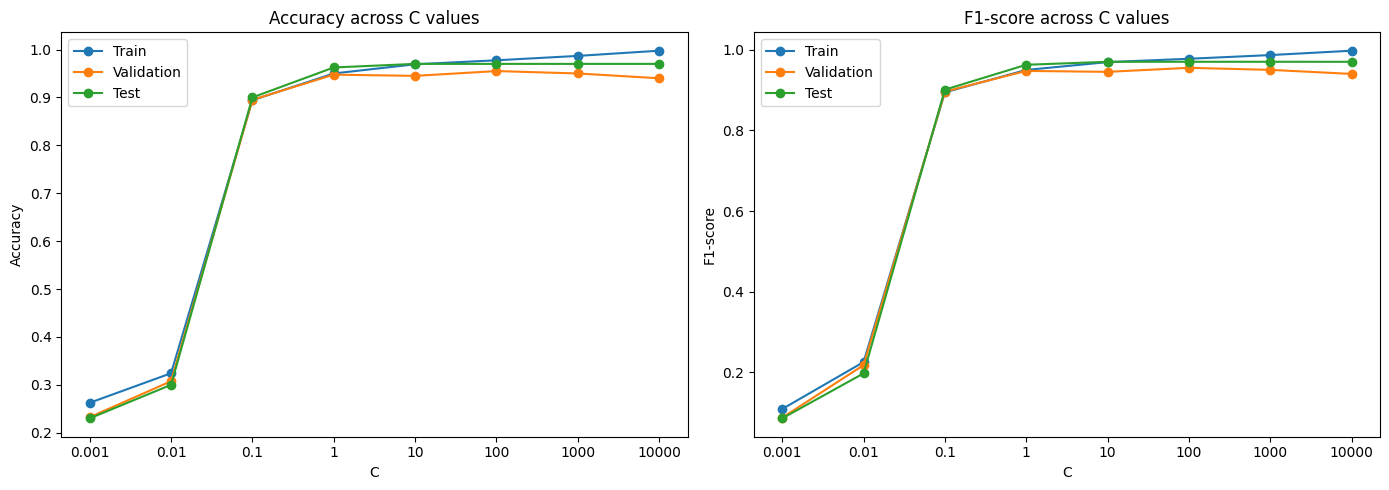

In [ ]:
# 2(b) - sweep over C values
C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
records = {'C': C_range,
           'train_acc': [], 'val_acc': [], 'test_acc': [],
           'train_f1':  [], 'val_f1':  [], 'test_f1':  []}

for C_val in C_range:
    svm = SVC(C=C_val, random_state=42)
    svm.fit(X_tr, y_tr)
    for Xs, ys, acc_key, f1_key in [
        (X_tr, y_tr, 'train_acc', 'train_f1'),
        (X_va, y_va, 'val_acc',   'val_f1'),
        (X_te, y_te, 'test_acc',  'test_f1')
    ]:
        pred = svm.predict(Xs)
        records[acc_key].append(accuracy_score(ys, pred))
        records[f1_key].append(f1_score(ys, pred, average='weighted'))

x_ticks = [str(c) for c in C_range]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, key in [('Train', 'train_acc'),
                   ('Validation', 'val_acc'),
                   ('Test', 'test_acc')]:
    ax1.plot(x_ticks, records[key], marker='o', label=label)
ax1.set_title('Accuracy across C values')
ax1.set_xlabel('C')
ax1.set_ylabel('Accuracy')
ax1.legend()

for label, key in [('Train', 'train_f1'),
                   ('Validation', 'val_f1'),
                   ('Test', 'test_f1')]:
    ax2.plot(x_ticks, records[key], marker='o', label=label)
ax2.set_title('F1-score across C values')
ax2.set_xlabel('C')
ax2.set_ylabel('F1-score')
ax2.legend()

plt.tight_layout()
plt.show()

In [3]:
# 2(c) - Best C based on validation performance
best_idx = np.argmax(records['val_acc'])
best_C = C_range[best_idx]
print(f"Best C based on validation accuracy: {best_C}")
print(f"  Val Accuracy : {records['val_acc'][best_idx]:.4f}")
print(f"  Test Accuracy: {records['test_acc'][best_idx]:.4f}")
print(f"  Test F1      : {records['test_f1'][best_idx]:.4f}")

Best C based on validation accuracy: 100
  Val Accuracy : 0.9550
  Test Accuracy: 0.9700
  Test F1      : 0.9701


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

df = pd.read_csv('data/mobile_price.csv')

# filter price range
df_filtered = df[df['price_range'] == 1].copy()

# select 4 feature cols
features = ['ram', 'int_memory', 'px_width', 'battery_power']
df_feat = df_filtered[features].copy()

# categorize into low/medium/high with 3:4:3 ratio


def categorize(series, name):
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    low_thresh = min_val + 0.3 * range_val
    high_thresh = min_val + 0.7 * range_val

    def label(x):
        if x <= low_thresh:
            return f'{name}_low'
        elif x <= high_thresh:
            return f'{name}_medium'
        else:
            return f'{name}_high'
    return series.apply(label)


for feat in features:
    df_feat[feat] = categorize(df_feat[feat], feat)

# one-hot encoded transaction format
transactions = pd.get_dummies(df_feat)
transactions = transactions.astype(bool)

print("Transaction shape:", transactions.shape)
print("Columns:", transactions.columns.tolist())

# 3(a) - frequent patterns with support >= 0.3
frequent_itemsets = fpgrowth(transactions, min_support=0.3, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
print("\nFrequent Itemsets (support >= 0.3):")
print(frequent_itemsets.to_string())

Transaction shape: (500, 12)
Columns: ['ram_ram_high', 'ram_ram_low', 'ram_ram_medium', 'int_memory_int_memory_high', 'int_memory_int_memory_low', 'int_memory_int_memory_medium', 'px_width_px_width_high', 'px_width_px_width_low', 'px_width_px_width_medium', 'battery_power_battery_power_high', 'battery_power_battery_power_low', 'battery_power_battery_power_medium']

Frequent Itemsets (support >= 0.3):
   support                                              itemsets
2    0.682                                      (ram_ram_medium)
3    0.416                            (px_width_px_width_medium)
5    0.414                  (battery_power_battery_power_medium)
4    0.412                        (int_memory_int_memory_medium)
7    0.318  (battery_power_battery_power_medium, ram_ram_medium)
0    0.316                           (int_memory_int_memory_low)
1    0.308                     (battery_power_battery_power_low)
6    0.306            (px_width_px_width_medium, ram_ram_medium)


In [ ]:
# 3(b) - association rules with support >= 0.3, confidence >= 0.4, lift >= 0.8
rules = association_rules(frequent_itemsets, metric='confidence',
                          min_threshold=0.4)
rules = rules[(rules['support'] >= 0.3) & (rules['lift'] >= 0.8)]
rules = rules.sort_values('lift', ascending=False)
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents',
      'support', 'confidence', 'lift']].to_string())


Association Rules:
                            antecedents                           consequents  support  confidence      lift
0  (battery_power_battery_power_medium)                      (ram_ram_medium)    0.318    0.768116  1.126270
1                      (ram_ram_medium)  (battery_power_battery_power_medium)    0.318    0.466276  1.126270
2            (px_width_px_width_medium)                      (ram_ram_medium)    0.306    0.735577  1.078559
3                      (ram_ram_medium)            (px_width_px_width_medium)    0.306    0.448680  1.078559


Explained variance ratio: [0.08380992 0.08104549]
Total variance captured: 0.1649


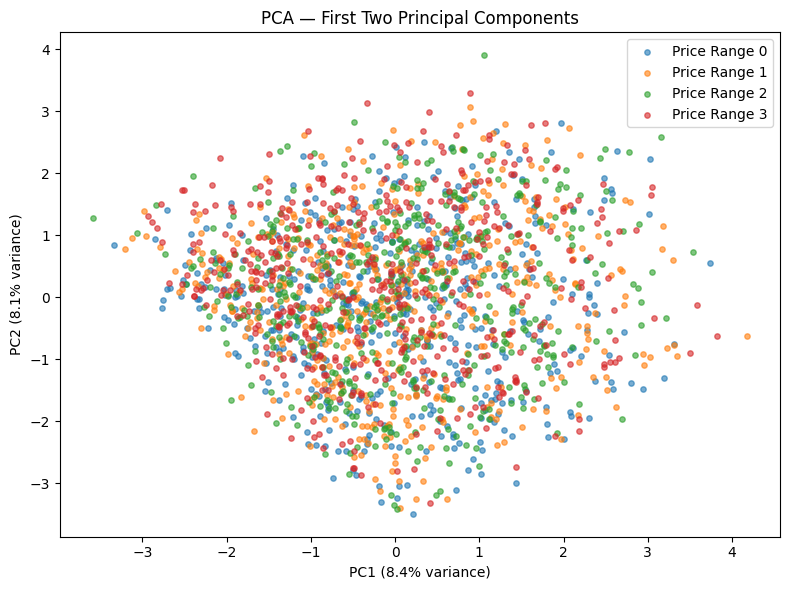

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

mobile_df = pd.read_csv('data/mobile_price.csv')
X_raw = mobile_df.drop('price_range', axis=1).values
y_true = mobile_df['price_range'].values

# 4(a) - Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

# 4(b) - PCA to 2D and scatterplot
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_std)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(8, 6))
for cls in np.unique(y_true):
    mask = y_true == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f'Price Range {cls}', alpha=0.6, s=15)
plt.title('PCA — First Two Principal Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

K-Means (all features) — Adjusted Rand Score: 0.0060


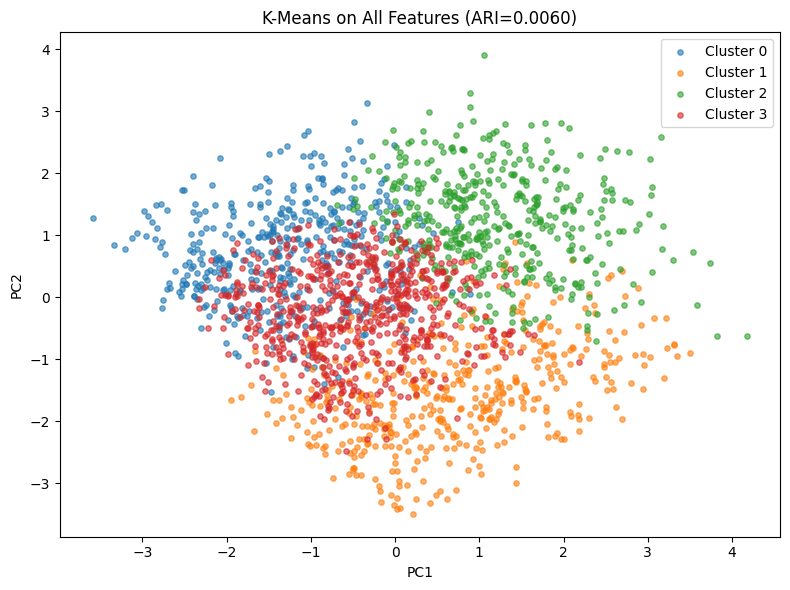

In [ ]:
# 4(c) - K-Means on all features
km_full = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_full = km_full.fit_predict(X_std)
ari_full = adjusted_rand_score(y_true, cluster_labels_full)
print(f"K-Means (all features) — Adjusted Rand Score: {ari_full:.4f}")

plt.figure(figsize=(8, 6))
for cl in np.unique(cluster_labels_full):
    mask = cluster_labels_full == cl
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f'Cluster {cl}', alpha=0.6, s=15)
plt.title(f'K-Means on All Features (ARI={ari_full:.4f})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

K-Means (PCA 2D) — Adjusted Rand Score: 0.0019


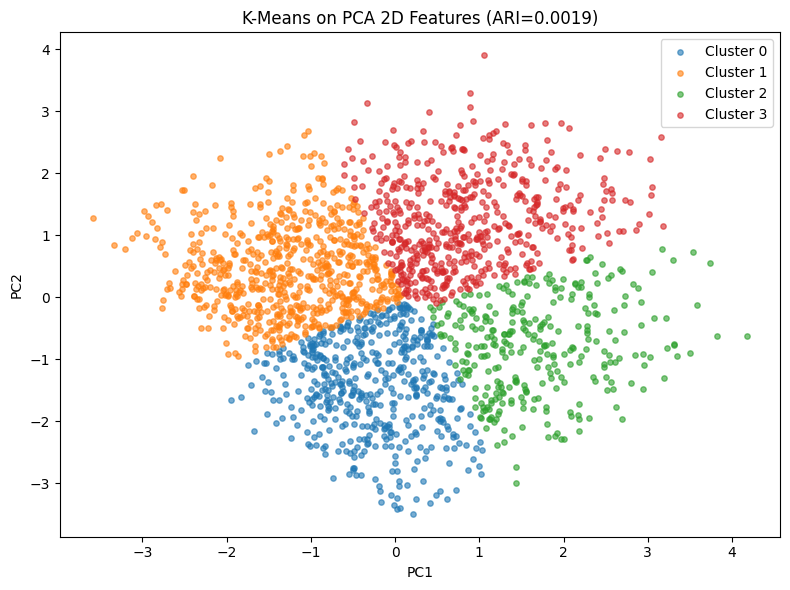


ARI drop from full→PCA: 0.0041
This reflects information lost during dimensionality reduction.


In [ ]:
# 4(d) - K-Means on PCA 2D features
km_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_pca = km_pca.fit_predict(X_2d)
ari_pca = adjusted_rand_score(y_true, cluster_labels_pca)
print(f"K-Means (PCA 2D) — Adjusted Rand Score: {ari_pca:.4f}")

plt.figure(figsize=(8, 6))
for cl in np.unique(cluster_labels_pca):
    mask = cluster_labels_pca == cl
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f'Cluster {cl}', alpha=0.6, s=15)
plt.title(f'K-Means on PCA 2D Features (ARI={ari_pca:.4f})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nARI drop from full→PCA: {ari_full - ari_pca:.4f}")
print("This reflects information lost during dimensionality reduction.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.metrics.cluster import adjusted_rand_score
from mlxtend.frequent_patterns import fpgrowth, association_rules
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/mobile_price.csv')
X = df.drop('price_range', axis=1).values
y = df['price_range'].values
feature_names = df.drop('price_range', axis=1).columns.tolist()

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X_std)

seeds = [0, 10, 42, 100, 999]

# ── Hungarian mapping for optimal cluster-to-label assignment ──


def hungarian_mapping(cluster_ids, ground_truth, k=4):
    cost_matrix = np.zeros((k, k))
    for c in range(k):
        for l in range(k):
            cost_matrix[c, l] = np.sum(
                (cluster_ids == c) & (ground_truth == l))
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    mapping = dict(zip(row_ind, col_ind))
    return np.array([mapping[c] for c in cluster_ids])


def evaluate_clustering(cluster_ids, ground_truth, k=4):
    mapped = hungarian_mapping(cluster_ids, ground_truth, k)
    return {
        'accuracy':  accuracy_score(ground_truth, mapped),
        'precision': precision_score(ground_truth, mapped,
                                     average='weighted', zero_division=0),
        'recall':    recall_score(ground_truth, mapped,
                                  average='weighted', zero_division=0),
        'f1':        f1_score(ground_truth, mapped,
                              average='weighted', zero_division=0),
        'ari':       adjusted_rand_score(ground_truth, cluster_ids)
    }

In [ ]:
# ════════════════════════════════════════════════════════
# STEP 1: Use ARM per price_range class to find
#         which features are most associated with each class
# ════════════════════════════════════════════════════════

def discretize_features(X_array, col_names, low_q=0.3, high_q=0.7):
    out = pd.DataFrame()
    for i, name in enumerate(col_names):
        col = pd.Series(X_array[:, i])
        t_low = col.quantile(low_q)
        t_high = col.quantile(high_q)
        out[name + '_low'] = col <= t_low
        out[name + '_med'] = (col > t_low) & (col <= t_high)
        out[name + '_high'] = col > t_high
    return out.astype(bool)


# ARM is run separately for each price_range class
# collect which features appear most in high-lift rules per class
feature_class_lift = pd.DataFrame(0.0,
                                  index=feature_names,
                                  columns=[0, 1, 2, 3])

for price_class in [0, 1, 2, 3]:
    subset_idx = np.where(y == price_class)[0]
    X_subset = X_std[subset_idx]

    transactions = discretize_features(X_subset, feature_names)

    freq = fpgrowth(transactions, min_support=0.1, use_colnames=True)
    if len(freq) == 0:
        continue

    rules = association_rules(freq, metric='lift', min_threshold=1.0)
    if len(rules) == 0:
        continue

    for feat in feature_names:
        matching = rules[rules['antecedents'].apply(
            lambda items: any(feat in item for item in items))]
        if len(matching) > 0:
            feature_class_lift.loc[feat, price_class] = matching['lift'].mean()

print("Per-class average lift per feature:")
print(feature_class_lift.round(3).to_string())

# compute the discriminative power of each feature
# how much its lift varies across classes
feature_discriminability = feature_class_lift.std(axis=1)
feature_discriminability = feature_discriminability / \
    feature_discriminability.mean()

print("\nFeature discriminability scores (ARM-derived):")
disc_sorted = feature_discriminability.sort_values(ascending=False)
for feat, score in disc_sorted.items():
    print(f"  {feat:<20}: {score:.4f}")

Per-class average lift per feature:
                   0      1      2      3
battery_power  1.079  1.119  1.126  1.062
blue           1.081  1.082  1.078  1.072
clock_speed    1.074  1.084  1.059  1.072
dual_sim       1.083  1.083  1.072  1.077
fc             1.209  1.206  1.146  1.145
four_g         1.085  1.081  1.067  1.077
int_memory     1.087  1.054  1.072  1.062
m_dep          1.076  1.071  1.085  1.078
mobile_wt      1.084  1.068  1.071  1.063
n_cores        1.065  1.074  1.056  1.054
pc             1.203  1.202  1.144  1.144
px_height      1.069  1.127  1.097  1.100
px_width       1.099  1.099  1.121  1.096
ram            1.087  1.152  1.159  1.064
sc_h           1.105  1.098  1.088  1.096
sc_w           1.095  1.096  1.068  1.098
talk_time      1.081  1.065  1.074  1.061
three_g        1.078  1.081  1.072  1.068
touch_screen   1.078  1.091  1.073  1.079
wifi           1.084  1.070  1.068  1.077

Feature discriminability scores (ARM-derived):
  ram                 : 3.1375
  f

In [ ]:
# ════════════════════════════════════════════════════════
# STEP 2: Select top-k most discriminative features
#         identified by ARM and run K-Means on those only
# ════════════════════════════════════════════════════════

# select top features by ARM discriminability
top_k = 5
top_features = disc_sorted.head(top_k).index.tolist()
print(f"\nTop {top_k} ARM-selected features: {top_features}")

# indices of selected features
selected_idx = [feature_names.index(f) for f in top_features]
X_arm_selected = X_std[:, selected_idx]

# test varying k for ablation study
k_values = [3, 5, 8, 10, 15, 20]
ablation_records = []

for k in k_values:
    top_k_feats = disc_sorted.head(k).index.tolist()
    sel_idx = [feature_names.index(f) for f in top_k_feats]
    X_sel = X_std[:, sel_idx]
    k_seed_scores = []
    for seed in seeds:
        km = KMeans(n_clusters=4, random_state=seed, n_init=10)
        k_seed_scores.append(evaluate_clustering(km.fit_predict(X_sel), y))
    ablation_records.append({
        'k': k,
        'accuracy': np.mean([s['accuracy'] for s in k_seed_scores]),
        'f1':       np.mean([s['f1'] for s in k_seed_scores]),
        'ari':      np.mean([s['ari'] for s in k_seed_scores])
    })

abl_df = pd.DataFrame(ablation_records).set_index('k')
print("\n=== Ablation: Number of ARM-Selected Features ===")
print(abl_df.round(4).to_string())

# best k from ablation are chosen
best_k = abl_df['ari'].idxmax()
print(f"\nBest k = {best_k} features")
top_features_final = disc_sorted.head(best_k).index.tolist()
selected_idx_final = [feature_names.index(f) for f in top_features_final]
X_arm_final = X_std[:, selected_idx_final]


Top 5 ARM-selected features: ['ram', 'fc', 'pc', 'battery_power', 'px_height']

=== Ablation: Number of ARM-Selected Features ===
    accuracy      f1     ari
k                           
3     0.4722  0.4636  0.2077
5     0.4419  0.4376  0.1713
8     0.3932  0.3943  0.1093
10    0.3187  0.3196  0.0324
15    0.2897  0.2897  0.0063
20    0.2962  0.2941  0.0058

Best k = 3 features


In [ ]:
# ════════════════════════════════════════════════════════
# STEP 3: Compare Original K-Means vs ARM-Selected K-Means
# ════════════════════════════════════════════════════════

orig_results = []
arm_results = []

for seed in seeds:
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10)
    orig_results.append(evaluate_clustering(
        km_orig.fit_predict(X_std), y))

    km_arm = KMeans(n_clusters=4, random_state=seed, n_init=10)
    arm_results.append(evaluate_clustering(
        km_arm.fit_predict(X_arm_final), y))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'ari']
method_names = ['Original K-Means', 'ARM-Selected K-Means']
all_results = [orig_results, arm_results]

print("=" * 55)
print(f"{'Metric':<12}", end="")
for name in method_names:
    print(f"{name:>22}", end="")
print()
print("=" * 55)

for m in metrics:
    print(f"{m:<12}", end="")
    for results in all_results:
        avg = np.mean([r[m] for r in results])
        print(f"{avg:>22.4f}", end="")
    print()

print("=" * 55)

print(f"\nPer-seed ARI:")
print(f"{'Seed':<8} {'Original':>12} {'ARM-Selected':>14} {'Δ':>8}")
for i, seed in enumerate(seeds):
    orig_ari = orig_results[i]['ari']
    arm_ari = arm_results[i]['ari']
    delta = arm_ari - orig_ari
    sign = '+' if delta >= 0 else ''
    print(f"{seed:<8} {orig_ari:>12.4f} {arm_ari:>14.4f}  {sign}{delta:.4f}")

Metric            Original K-Means  ARM-Selected K-Means
accuracy                    0.2962                0.4722
precision                   0.2959                0.4601
recall                      0.2962                0.4722
f1                          0.2941                0.4636
ari                         0.0058                0.2077

Per-seed ARI:
Seed         Original   ARM-Selected        Δ
0              0.0053         0.2070  +0.2018
10             0.0056         0.2080  +0.2024
42             0.0060         0.2078  +0.2018
100            0.0055         0.2080  +0.2025
999            0.0068         0.2078  +0.2010


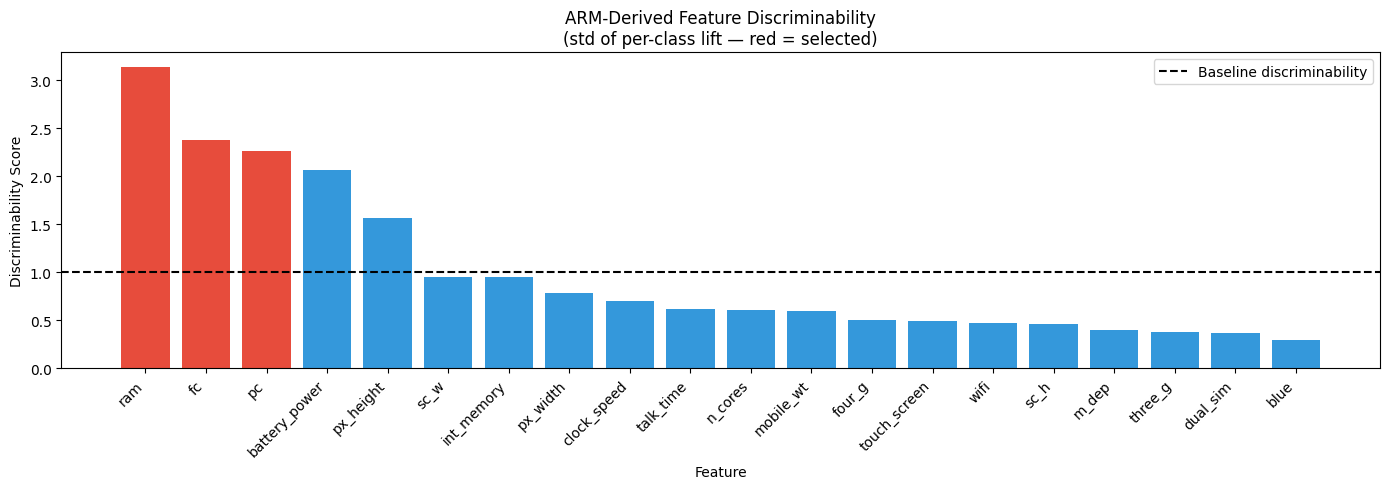

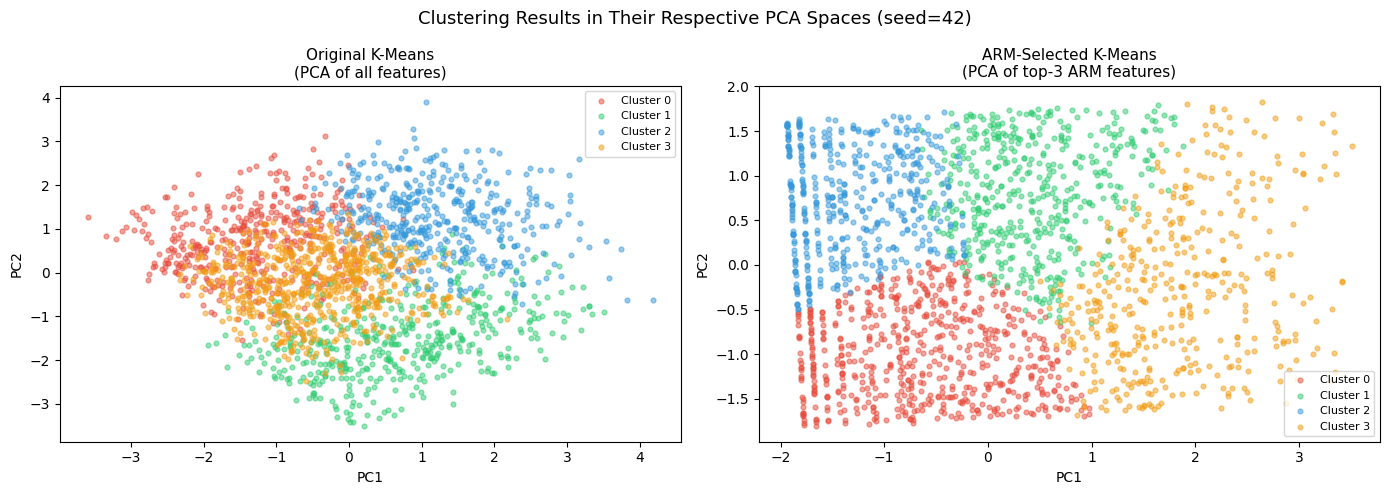

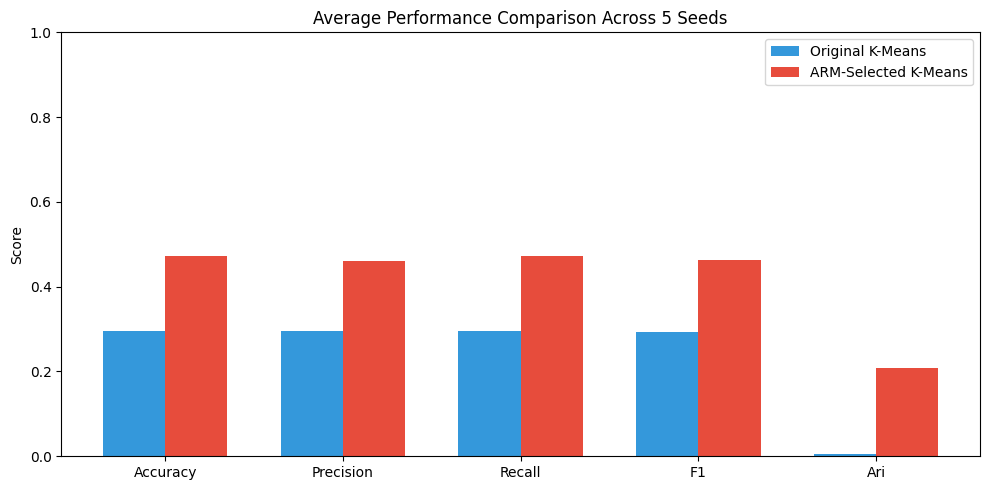

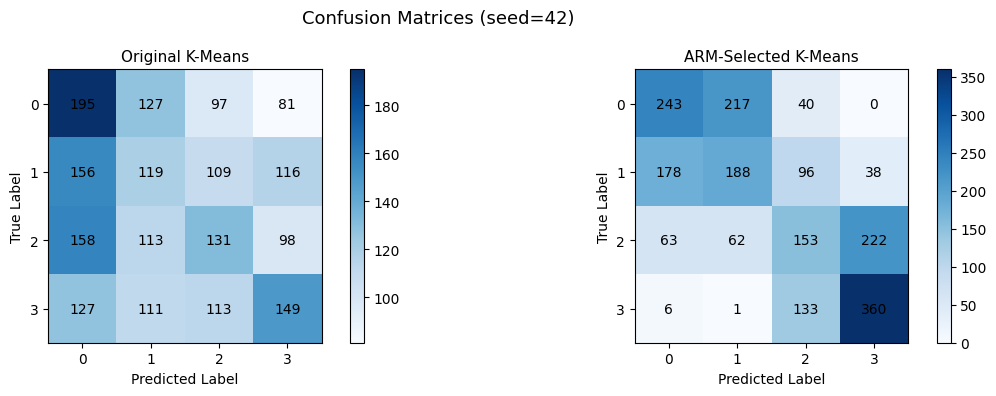

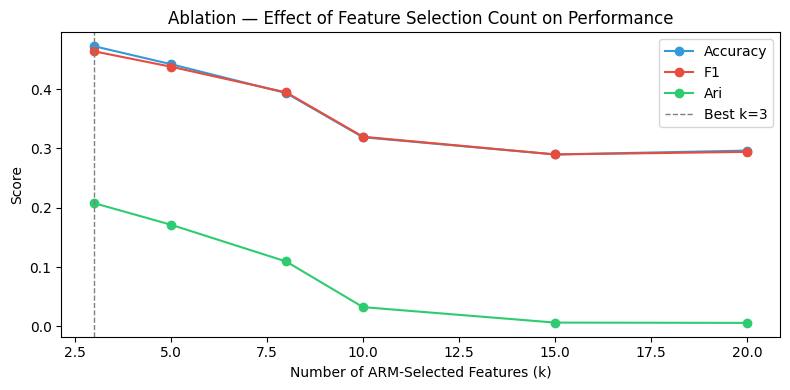

In [ ]:
# ════════════════════════════════════════════════════════
# STEP 4: Visualizations
# ════════════════════════════════════════════════════════

# discriminability bar chart
plt.figure(figsize=(14, 5))
colors = ['#e74c3c' if f in top_features_final else '#3498db'
          for f in disc_sorted.index]
plt.bar(disc_sorted.index, disc_sorted.values, color=colors)
plt.axhline(y=1.0, color='black', linestyle='--',
            label='Baseline discriminability')
plt.title('ARM-Derived Feature Discriminability\n'
          '(std of per-class lift — red = selected)', fontsize=12)
plt.xlabel('Feature')
plt.ylabel('Discriminability Score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Compute PCA on the ARM-selected features only
pca_arm = PCA(n_components=2, random_state=42)
X_arm_2d = pca_arm.fit_transform(X_arm_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

# left - riginal K-Means in its own PCA space
km_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
cl_orig = km_orig.fit_predict(X_std)
for c in range(4):
    mask = cl_orig == c
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=plot_colors[c], alpha=0.5, s=12,
                label=f'Cluster {c}')
ax1.set_title('Original K-Means\n(PCA of all features)', fontsize=11)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(fontsize=8)

# right - ARM K-Means in ARM feature PCA space
km_arm = KMeans(n_clusters=4, random_state=42, n_init=10)
cl_arm = km_arm.fit_predict(X_arm_final)
for c in range(4):
    mask = cl_arm == c
    ax2.scatter(X_arm_2d[mask, 0], X_arm_2d[mask, 1],
                c=plot_colors[c], alpha=0.5, s=12,
                label=f'Cluster {c}')
ax2.set_title(
    f'ARM-Selected K-Means\n(PCA of top-{best_k} ARM features)', fontsize=11)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(fontsize=8)

plt.suptitle(
    'Clustering Results in Their Respective PCA Spaces (seed=42)', fontsize=13)
plt.tight_layout()
plt.show()

# average metrics
x = np.arange(len(metrics))
width = 0.35
orig_avgs = [np.mean([r[m] for r in orig_results]) for m in metrics]
arm_avgs = [np.mean([r[m] for r in arm_results]) for m in metrics]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, orig_avgs, width,
       label='Original K-Means', color='#3498db')
ax.bar(x + width/2, arm_avgs, width,
       label='ARM-Selected K-Means', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Average Performance Comparison Across 5 Seeds')
ax.legend()
plt.tight_layout()
plt.show()

# confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, title, X_fit in [(ax1, 'Original K-Means', X_std),
                         (ax2, 'ARM-Selected K-Means', X_arm_final)]:
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    cl = km.fit_predict(X_fit)
    mapped = hungarian_mapping(cl, y)
    cm = confusion_matrix(y, mapped)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax)

plt.suptitle('Confusion Matrices (seed=42)', fontsize=13)
plt.tight_layout()
plt.show()

# ablation plot
fig, ax = plt.subplots(figsize=(8, 4))
for col, color in [('accuracy', '#3498db'),
                   ('f1',       '#e74c3c'),
                   ('ari',      '#2ecc71')]:
    ax.plot(abl_df.index, abl_df[col], marker='o',
            label=col.capitalize(), color=color)
ax.axvline(x=best_k, color='gray', linestyle='--',
           linewidth=1, label=f'Best k={best_k}')
ax.set_xlabel('Number of ARM-Selected Features (k)')
ax.set_ylabel('Score')
ax.set_title('Ablation — Effect of Feature Selection Count on Performance')
ax.legend()
plt.tight_layout()
plt.show()